In [2]:
import matplotlib.pyplot as plt
import numpy as np

from model_ranking.utils import load_h5
from model_ranking.augmentations import (
    DEFAULT_TRAIN_AUGMENTATIONS,
    get_default_augmentations,
)
from torch_em.transform import get_augmentations
from pytorch3dunet.datasets.utils import calculate_stats

In [4]:
VNC_path = "/scratch/talks/data/VNC/resized_pixels/test.h5"
VNC_data = load_h5(VNC_path, "raw")
VNC_labels = load_h5(VNC_path, "labels")

VNC_patch shape: (1, 128, 128)


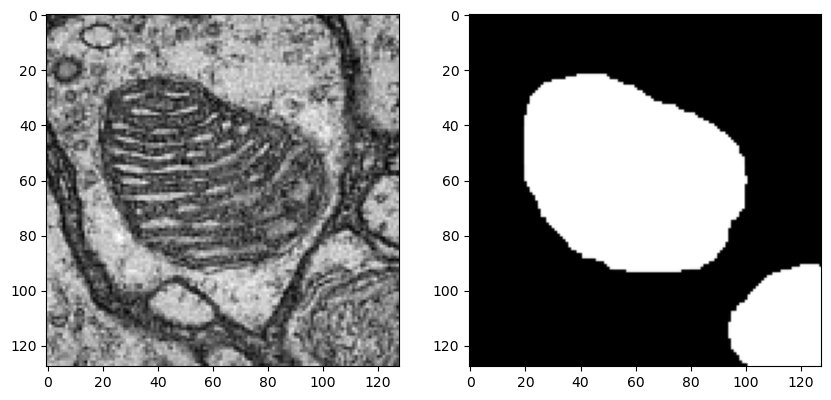

In [ ]:
VNC_raw = VNC_data[0:1, :128, :128]
VNC_label = VNC_labels[0:1, :128, :128]
print(f"VNC_patch shape: {VNC_raw.shape}")
_, axs = plt.subplots(1, 2, figsize=(10, 5))
_ = axs[0].imshow(VNC_raw.squeeze(), cmap="gray")
_ = axs[1].imshow(VNC_label.squeeze(), cmap="gray")
plt.show()

In [ ]:
augs_2D = [
    "RandomHorizontalFlip",
    "RandomVerticalFlip"
    "RandomRotate",
]

augs = get_augmentations(ndim=3, transforms=augs_2D)

VNC_transformed shape: torch.Size([1, 1, 256, 256])


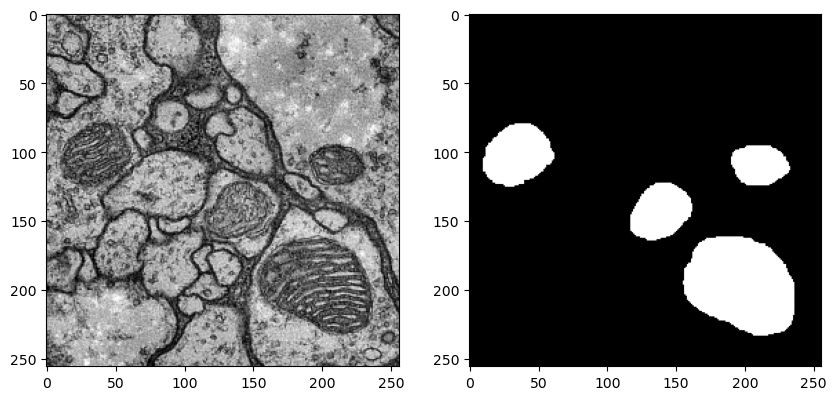

In [32]:
VNC_raw_T, VNC_label_T = augs(VNC_raw, VNC_label)
print(f"VNC_transformed shape: {VNC_raw_T.shape}")
_, axs = plt.subplots(1, 2, figsize=(10, 5))
_ = axs[0].imshow(VNC_raw_T.squeeze(), cmap="gray")
_ = axs[1].imshow(VNC_label_T.squeeze(), cmap="gray")
plt.show()

In [33]:
from pytorch3dunet.augment.transforms import Transformer, Compose

transformer = Transformer(DEFAULT_TRAIN_AUGMENTATIONS, calculate_stats(VNC_data))
raw_transform, label_transform = transformer.raw_transform(), transformer.label_transform()

In [38]:
from torch_em.transform import (
    PadIfNecessary,
)
patch_shape= (1, 256, 256)
raw_transform = Compose([
    PadIfNecessary(patch_shape),
    raw_transform,
]
)
label_transform = Compose([
    PadIfNecessary(patch_shape),
    label_transform,
]
)

In [6]:
raw_T, label_T = get_default_augmentations(
    DEFAULT_TRAIN_AUGMENTATIONS, calculate_stats(VNC_data)
)

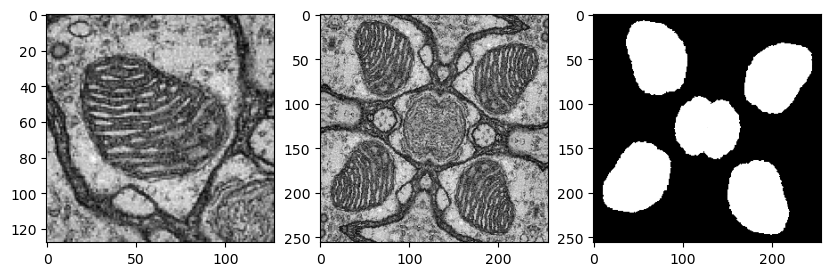

In [43]:
VNC_raw_T2 = raw_transform(VNC_raw)
VNC_label_T2 = label_transform(VNC_label)
_, axs = plt.subplots(1, 3, figsize=(10, 5))
_ = axs[0].imshow(VNC_raw.squeeze(), cmap="gray")
_ = axs[1].imshow(VNC_raw_T2.squeeze(), cmap="gray")
_ = axs[2].imshow(VNC_label_T2.squeeze(), cmap="gray")
plt.show()